In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

Library numpy untuk membantu manipulasi array dan matriks. Library matplotlib.pyplot untuk menampilkan hasil citra ke dalam bentuk visual. library cv2. untuk membaca file gambar, mengubah format warna, melakukan transformasi citra, serta berbagai operasi lain seperti filtering, deteksi objek, dan manipulasi piksel.

Text(0.5, 1.0, 'Gambar Grayscale')

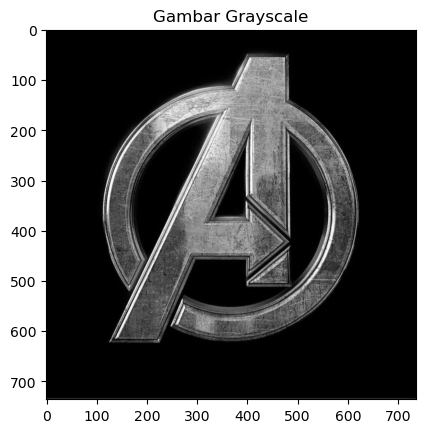

In [2]:
img_1 = plt.imread("doomsday.jpg")
grayscale = cv2.cvtColor(img_1, cv2.COLOR_BGR2GRAY)
plt.imshow(grayscale , cmap='gray')
plt.title('Gambar Grayscale')

gambar doomsday.jpg dibaca menggunakan plt.imread yang menghasilkan array NumPy dalam format RGB. berikutnya cv2.cvtColor dipanggil dengan flag COLOR_BGR2GRAY yang mengasumsikan input dalam format BGR.Setelah dikonversi, gambar grayscale ditampilkan menggunakan plt.imshow dengan parameter cmap='gray'.

In [3]:
nilai = 1 / 1.4142135623730950488016887242097  
LPF = np.array([nilai, nilai])
HPF = np.array([nilai, -nilai])

def convo_h(image, kernel):

    ukuran_kernel = len(kernel)
    padd = np.pad(image, ((0, 0), (0, ukuran_kernel)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(conv.shape[0]):
        for j in range(conv.shape[1]):
            for x in range(ukuran_kernel):
                conv[i][j] += padd[i][j + x] * kernel[x]
    return conv


def convo_v(image, kernel):

    ukuran_kernel = len(kernel)
    padd = np.pad(image, ((0, ukuran_kernel), (0, 0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(conv.shape[0]):
        for j in range(conv.shape[1]):
            for x in range(ukuran_kernel):
                conv[i][j] += padd[i + x][j] * kernel[x]
    return conv


def downsampling_h(image):

    baris = image.shape[0]
    kolom = int(image.shape[1] / 2)
    downsampled = np.zeros((baris, kolom))
    for i in range(baris):
        indeks = 0
        for j in range(kolom):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled


def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = image.shape[1]
    downsampled = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2
    return downsampled

def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val == 0:
        return np.zeros_like(image)
    return (image - min_val) / (max_val - min_val) * 255

def wavelet_dekomposisi(image):

    k1 = convo_h(image, LPF)
    ds1 = downsampling_h(k1)
    k2 = convo_v(ds1, LPF)
    approximation = downsampling_v(k2)
    approximation = normalisasi(approximation)

    k1 = convo_h(image, LPF)
    ds1 = downsampling_h(k1)
    k2 = convo_v(ds1, HPF)
    horizontal = downsampling_v(k2)
    horizontal = normalisasi(horizontal)

    k1 = convo_h(image, HPF)
    ds1 = downsampling_h(k1)
    k2 = convo_v(ds1, LPF)
    vertikal = downsampling_v(k2)
    vertikal = normalisasi(vertikal)

    k1 = convo_h(image, HPF)
    ds1 = downsampling_h(k1)
    k2 = convo_v(ds1, HPF)
    diagonal = downsampling_v(k2)
    diagonal = normalisasi(diagonal)

    return approximation, horizontal, vertikal, diagonal

Prosesnya dimulai dari pendefinisian dua filter dasar, LPF (Low Pass Filter) dan HPF (High Pass Filter) yang masing-masing berisi koefisien [nilai, nilai] dan [nilai, -nilai] dengan nilai 1/√2 agar hasil konvolusi tetap ternormalisasi.Fungsi convo_h dan convo_v bertugas melakukan konvolusi 1D secara horizontal dan vertikal. Keduanya terlebih dahulu melakukan zero-padding pada sisi kanan atau bawah gambar agar ukuran output tetap sama dengan input, lalu menggeser kernel sepanjang baris atau kolom sambil mengakumulasikan hasil perkalian elemen. Setelah konvolusi, downsampling_h dan downsampling_v mengambil setiap kolom atau baris genap saja (indeks 0, 2, 4, ...) sehingga ukuran gambar tereduksi setengahnya.Fungsi normalisasi kemudian memetakan nilai piksel hasil konvolusi ke rentang 0–255 menggunakan min-max normalization, dengan penanganan khusus jika seluruh nilai gambar identik agar tidak terjadi pembagian nol.wavelet_dekomposisi yang menghasilkan empat sub-band. Approximation diperoleh dengan menerapkan LPF secara horizontal lalu LPF secara vertikal, menangkap informasi frekuensi rendah di kedua arah sehingga hasilnya menyerupai versi blur dari gambar asli. Horizontal menggunakan LPF horizontal dan HPF vertikal, sehingga hanya tepi horizontal yang menonjol. Vertikal menggunakan HPF horizontal dan LPF vertikal untuk menangkap tepi vertikal. Terakhir, Diagonal menerapkan HPF di kedua arah untuk menangkap detail diagonal dan tekstur frekuensi tinggi. Keempat sub-band ini masing-masing berukuran setengah dari gambar asli, baik lebar maupun tingginya.

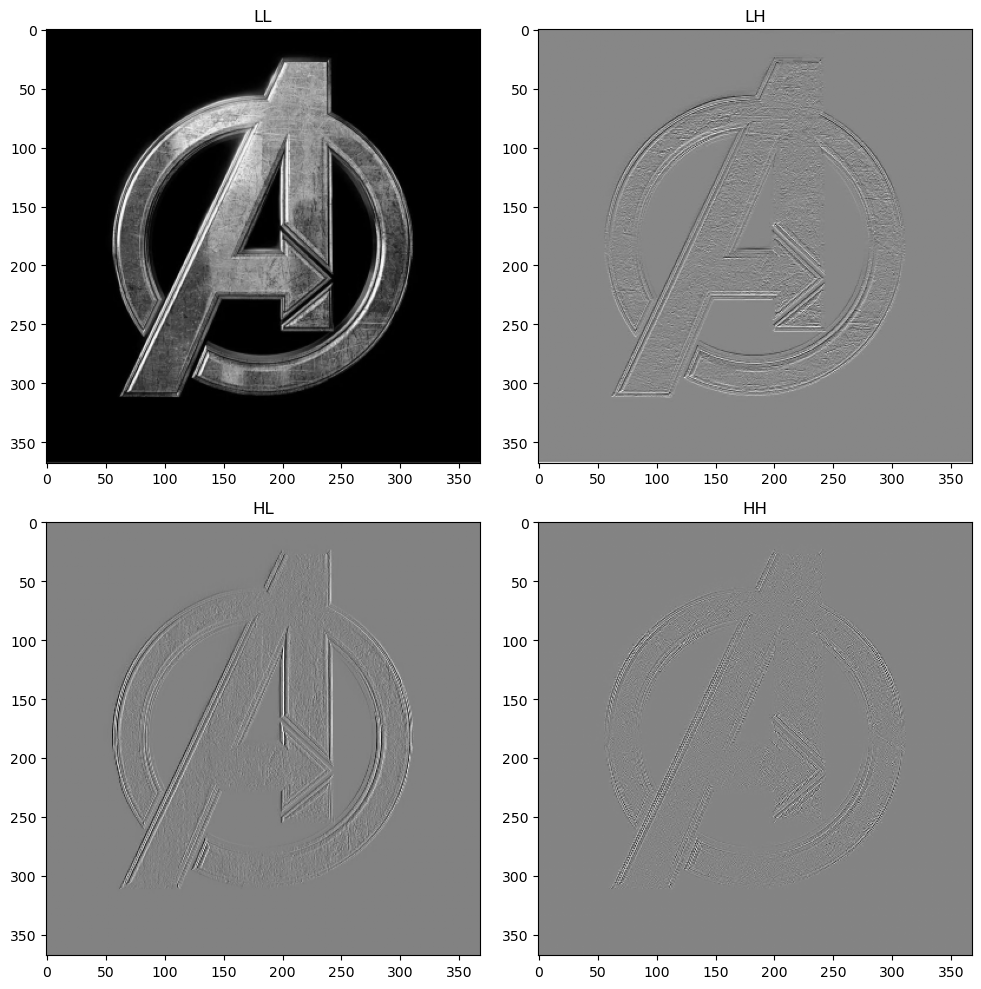

In [32]:
approximation, horizontal, vertikal, diagonal = wavelet_dekomposisi(grayscale)

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(approximation, cmap='gray')
plt.title('LL')

plt.subplot(2, 2, 2)
plt.imshow(horizontal, cmap='gray')
plt.title('LH')

plt.subplot(2, 2, 3)
plt.imshow(vertikal, cmap='gray')
plt.title('HL')

plt.subplot(2, 2, 4)
plt.imshow(diagonal, cmap='gray')
plt.title('HH')

plt.tight_layout()
plt.show()

 fungsi wavelet_dekomposisi dipanggil dengan gambar grayscale sebagai input, dan hasilnya langsung di-unpack ke empat variabel sekaligus LL, LH, HL, dan HH.Setelah itu, sebuah figure berukuran 10×10 inci dibuat menggunakan plt.figure(figsize=(10, 10)), lalu dibagi menjadi grid 2×2 menggunakan plt.subplot(2, 2, n) di mana angka ketiga menunjukkan posisi plot 1 di kiri atas, 2 di kanan atas, 3 di kiri bawah, dan 4 di kanan bawah. Setiap sub-plot menampilkan satu sub-band dengan cmap='gray' dan diberi judul yang sesuai.

In [5]:
def threshold_manual(img, nilai_threshold):
    h, w = img.shape
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            if img[i,j] > nilai_threshold:
                hasil[i,j] = 255
            else:
                hasil[i,j] = 0
    return hasil

Fungsi ini mengimplementasikan thresholding biner secara manual tanpa menggunakan fungsi bawaan seperti cv2.threshold

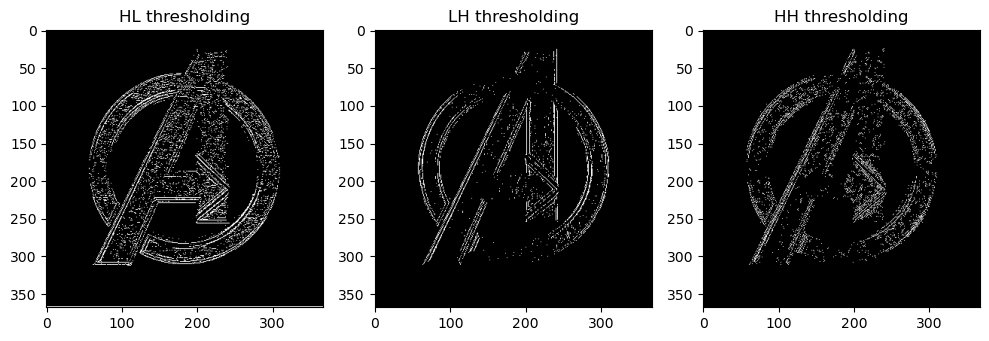

In [33]:
hasil_LH = threshold_manual(horizontal, nilai_threshold=150)
hasil_HL = threshold_manual(vertikal, nilai_threshold=150)
hasil_HH = threshold_manual(diagonal, nilai_threshold=150)

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(hasil_LH, cmap='gray')
plt.title('HL thresholding')

plt.subplot(1, 3, 2)
plt.imshow(hasil_HL, cmap='gray')
plt.title('LH thresholding')

plt.subplot(1, 3, 3)
plt.imshow(hasil_HH, cmap='gray')
plt.title('HH thresholding')

plt.tight_layout()
plt.show()

menerapkan fungsi threshold_manual pada ketiga sub-band frekuensi tinggi hasil dekomposisi wavelet HL, LH, dan HH  masing-masing dengan nilai threshold 150.

In [14]:
kernel = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
])

def metode_satu(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
                        else:
                            if hasil[i, j] != 255:
                                hasil[i, j] = 0
    return hasil

def metode_dua(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

def closing(image, kernel):
    hasil_dilation = metode_satu(image, kernel)  
    hasil_closing  = metode_dua(hasil_dilation, kernel)  
    return hasil_closing

mengimplementasikan operasi morphological closing secara manual menggunakan kernel berbentuk diamond 5×5.metode_satu adalah implementasi dilasi, ia mengiterasi setiap piksel, dan jika menemukan piksel putih (255), kernel akan "dicap" ke area sekitarnya sesuai posisi elemen kernel yang bernilai 1.metode_dua adalah implementasi erosi, cara kerjanya berlawanan dengan dilasi. Untuk setiap piksel, ia memeriksa apakah seluruh area di sekitarnya yang bersesuaian dengan elemen kernel bernilai 1 juga merupakan piksel putih. Fungsi closing kemudian menggabungkan keduanya dengan urutan dilasi dulu, baru erosi. 

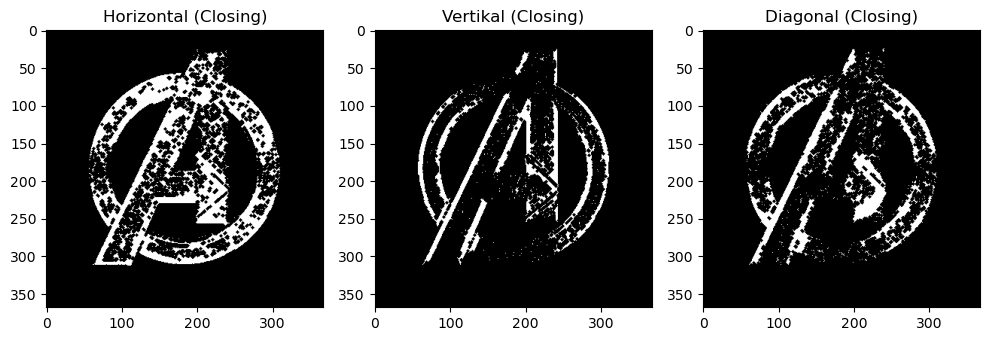

In [15]:
closing_LH = closing(hasil_LH, kernel)
closing_HL = closing(hasil_HL, kernel)
closing_HH = closing(hasil_HH, kernel)

plt.figure(figsize=(10, 10))

plt.subplot(1, 3, 1)
plt.imshow(closing_LH, cmap='gray')
plt.title('Horizontal (Closing)')

plt.subplot(1, 3, 2)
plt.imshow(closing_HL, cmap='gray')
plt.title('Vertikal (Closing)')

plt.subplot(1, 3, 3)
plt.imshow(closing_HH, cmap='gray')
plt.title('Diagonal (Closing)')

plt.tight_layout()
plt.show()


menerapkan fungsi closing pada ketiga hasil thresholding sebelumnya — hasil_LH, hasil_HL, dan hasil_HH — masing-masing menggunakan kernel diamond yang sama. Hasilnya disimpan ke variabel closing_LH, closing_HL, dan closing_HH.

In [ ]:
def upsampling_v(image):
    baris = image.shape[0] * 2
    kolom = image.shape[1]
    upsampled = np.zeros((baris, kolom))
    for i in range(image.shape[0]):
        for j in range(kolom):
            upsampled[i * 2][j] = image[i][j]
    return upsampled


def upsampling_h(image):
    baris = image.shape[0]
    kolom = image.shape[1] * 2
    upsampled = np.zeros((baris, kolom))
    for i in range(baris):
        for j in range(image.shape[1]):
            upsampled[i][j * 2] = image[i][j]
    return upsampled


def rekonstruksi(LL, LH, HL, HH):
    # Cabang L (dari LL dan LH)
    up_LL      = upsampling_v(LL)
    konvolusiL = convo_v(up_LL, LPF)

    up_LH      = upsampling_v(LH)
    konvolusiH = convo_v(up_LH, HPF)

    up_gabung_L  = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2  = convo_h(up_gabung_L, LPF)

    up_HL      = upsampling_v(HL)
    konvolusiL = convo_v(up_HL, LPF)

    up_HH      = upsampling_v(HH)
    konvolusiH = convo_v(up_HH, HPF)

    up_gabung_H  = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2  = convo_h(up_gabung_H, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return normalisasi(hasil).astype(np.uint8)

def wavelet_dekomposisi(image):
    k1 = convo_h(image, LPF)
    ds1 = downsampling_h(k1)
    k2 = convo_v(ds1, LPF)
    approximation = downsampling_v(k2)
    approximation = normalisasi(approximation)

    k1 = convo_h(image, LPF)
    ds1 = downsampling_h(k1)
    k2 = convo_v(ds1, HPF)
    horizontal = downsampling_v(k2)
    horizontal = normalisasi(horizontal)

    k1 = convo_h(image, HPF)
    ds1 = downsampling_h(k1)
    k2 = convo_v(ds1, LPF)
    vertikal = downsampling_v(k2)
    vertikal = normalisasi(vertikal)

    k1 = convo_h(image, HPF)
    ds1 = downsampling_h(k1)
    k2 = convo_v(ds1, HPF)
    diagonal = downsampling_v(k2)
    diagonal = normalisasi(diagonal)

    return approximation, horizontal, vertikal, diagonal

approximation, horizontal, vertikal, diagonal = wavelet_dekomposisi(grayscale)

engimplementasikan rekonstruksi inverse wavelet — kebalikan dari dekomposisi yang sudah dijelaskan sebelumnya. Dua fungsi upsampling bekerja dengan cara menyisipkan nol di antara setiap piksel, sehingga upsampling_v menggandakan jumlah baris dengan menempatkan nilai asli di baris genap dan membiarkan baris ganjil tetap nol, sedangkan upsampling_h melakukan hal yang sama secara horizontal pada kolom.Fungsi rekonstruksi menerima keempat sub-band — LL, LH, HL, HH — dan memprosesnya dalam dua cabang besar. Cabang pertama menangani pasangan LL dan LH yang keduanya berasal dari jalur LPF horizontal: masing-masing di-upsample secara vertikal, lalu dikonvolusi dengan filter yang sesuai (LPF untuk LL, HPF untuk LH), kemudian dijumlahkan dan di-upsample secara horizontal, dan hasilnya dikonvolusi dengan LPF horizontal menghasilkan konvolusiL2. Cabang kedua melakukan hal serupa untuk pasangan HL dan HH yang berasal dari jalur HPF horizontal, menghasilkan konvolusiH2 setelah dikonvolusi dengan HPF horizontal. Kedua cabang kemudian dijumlahkan menjadi hasil yang merepresentasikan gambar yang telah direkonstruksi, lalu dinormalisasi ke rentang 0–255 dan dikonversi ke uint8.

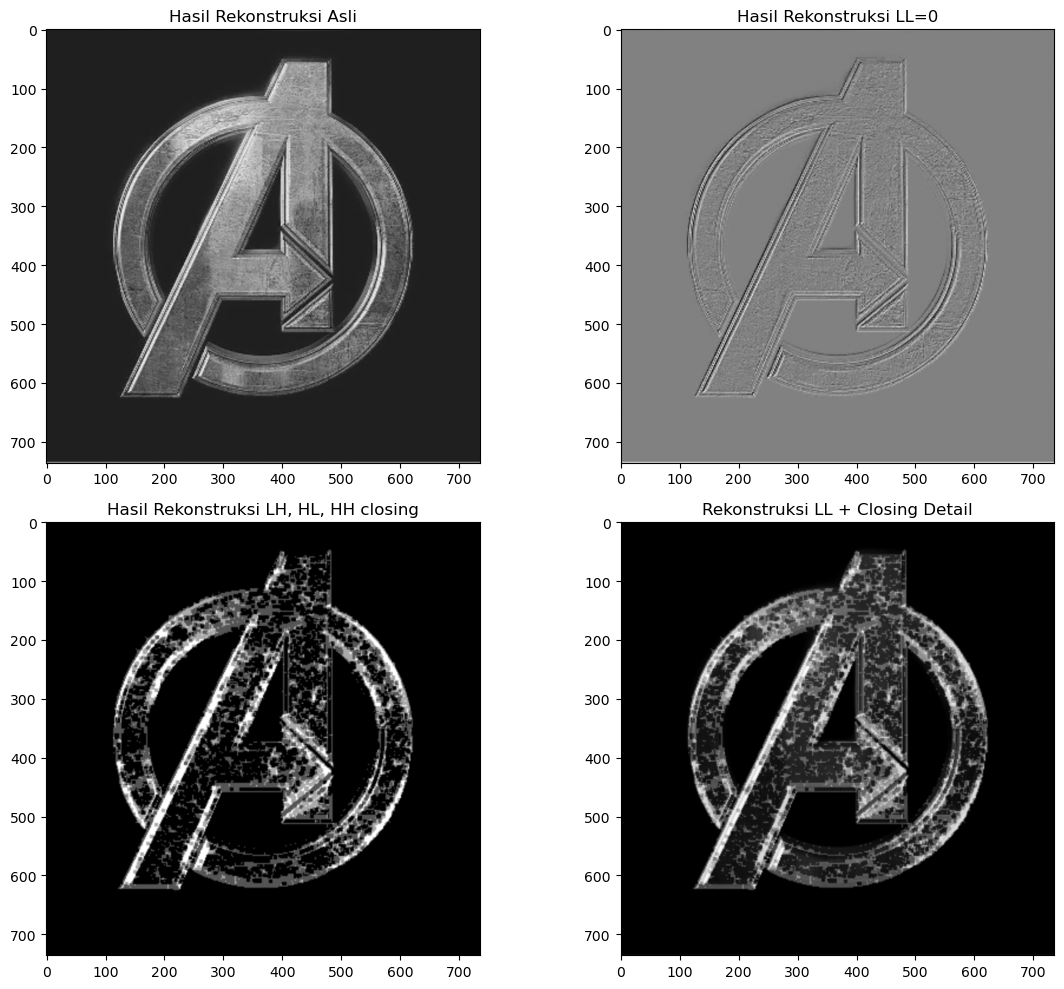

In [46]:
def rekonstruksi(LL, LH, HL, HH):
    target_h = LL.shape[0] * 2
    target_w = LL.shape[1] * 2

    LL_up = cv2.resize(LL.astype(np.float32), (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    LH_up = cv2.resize(LH.astype(np.float32), (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    HL_up = cv2.resize(HL.astype(np.float32), (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    HH_up = cv2.resize(HH.astype(np.float32), (target_w, target_h), interpolation=cv2.INTER_LINEAR)

    hasil = LL_up + LH_up + HL_up + HH_up
    return normalisasi(hasil).astype(np.uint8)

LL, LH, HL, HH = wavelet_dekomposisi(grayscale)

kernel = np.array([[1,1,1],[1,1,1],[1,1,1]], dtype=np.float32)

def closing(image, kernel):
    return metode_dua(metode_satu(image, kernel), kernel)

rekonstruksi_asli = rekonstruksi(LL, LH, HL, HH)

LL_nol = np.zeros_like(LL)
rekonstruksi_LL0 = rekonstruksi(LL_nol, LH, HL, HH)

hasil_LH = threshold_manual(LH, nilai_threshold=150)
hasil_HL = threshold_manual(HL, nilai_threshold=150)
hasil_HH = threshold_manual(HH, nilai_threshold=150)

closing_LH = closing(hasil_LH, kernel)
closing_HL = closing(hasil_HL, kernel)
closing_HH = closing(hasil_HH, kernel)

rekonstruksi_closing = rekonstruksi(LL_nol, closing_LH, closing_HL, closing_HH)

rekonstruksi_bonus = rekonstruksi(LL, closing_LH, closing_HL, closing_HH)

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(rekonstruksi_asli, cmap='gray')
plt.title('Hasil Rekonstruksi Asli')

plt.subplot(2, 2, 2)
plt.imshow(rekonstruksi_LL0, cmap='gray')
plt.title('Hasil Rekonstruksi LL=0')

plt.subplot(2, 2, 3)
plt.imshow(rekonstruksi_closing, cmap='gray')
plt.title('Hasil Rekonstruksi LH, HL, HH closing')

plt.subplot(2, 2, 4)
plt.imshow(rekonstruksi_bonus, cmap='gray')
plt.title('Rekonstruksi LL + Closing Detail')

plt.tight_layout()
plt.show()

fungsi rekonstruksi yang baru cukup memperbesar setiap sub-band ke ukuran dua kali lipat menggunakan cv2.resize dengan interpolasi bilinear, lalu menjumlahkan keempatnya langsung. Pendekatan ini lebih praktis meski tidak seketat rekonstruksi wavelet matematis, karena interpolasi bilinear mengisi nilai antar piksel dengan perkiraan yang lebih halus dibanding zero-insertion sebelumnya. Kernel juga diganti dari diamond 5×5 menjadi kotak 3×3 penuh yang lebih sederhana.rekonstruksi_asli adalah baseline yang menggabungkan semua sub-band tanpa modifikasi apapun, hasilnya mendekati gambar grayscale awal. rekonstruksi_LL0 mengganti sub-band LL dengan matriks nol sehingga informasi frekuensi rendah dihilangkan sepenuhnya — yang tersisa hanya kontribusi tepi dan detail dari LH, HL, dan HH, sehingga hasil visualnya akan terlihat seperti gambar tepi tanpa latar. rekonstruksi_closing selangkah lebih jauh dengan menerapkan threshold dan closing pada ketiga sub-band frekuensi tinggi sebelum direkonstruksi tanpa LL, sehingga hanya tepi yang sudah diperhalus dan dibersihkan yang masuk ke hasil akhir. Terakhir, rekonstruksi_bonus menggabungkan LL asli dengan sub-band detail yang sudah melalui closing — ini menghasilkan gambar yang masih memiliki struktur dan kecerahan keseluruhan dari LL, namun detail frekuensi tingginya sudah diperhalus, sehingga hasilnya cenderung lebih bersih dari noise dibanding rekonstruksi asli.